## Simulating CAR T-Cell Therapy with Patient Preconditioning

This notebook simulates the effect of CAR T-Cell therapy
preconditioned by sequential administration of chemotherapy
based on the ODEs in [this paper](https://link.springer.com/article/10.1007/s11538-021-00869-5).

In [329]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Model parameters

These are the parameters listed in Table 1, with parameters listed
in the same order as they appear in the table. They are listed
exactly as they appear with the only exception being $b$, which is given
as $1/b$ but listed as $b$ here.

In [330]:
# parameters are listedin the following order:
# a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma

PARAMS_PAT_1234 = [
    [2.55e-1,     1.76e-1,    5.14e-1,       5.14e-1],
    [5e-13,       5e-13,      1 / 9.804e8,   1 / 9.804e8],
    [2.03,        2.03,       5.80,          4.23],
    [2.25,        2.25,       2.25,          2.25],
    [1.4e3,       4.7e4,      1.3e4,         1.3e4],
    [1.1e-2,      7.46e-3,    2.7e-2,        2.7e-2],
    [2.42e-1,     1.65e-1,    6.0e-1,        6.0e-1],
    [1.65e9,      1.65e9,     1.65e8,        1.65e8],
    [2.019e5,     7.0e7,      2.0e7,         2.0e7],
    [1.395,       1.419,      1.43,          1.43],
    [7e-3,        3.4e-2,     2e-2,          2e-2],
    [2.93e-1,     2.93e-1,    2.93e-1,       2.93e-1],
    [3.42e-11,    6.716e-11,  3.42e-10,      3.42e-10],
    [3.0e-11,     3.0e-11,    1.53e-9,       1.53e-9],
    [3.05e-1,     3.05e-1,    2.5e-1,        3.6e-1],
    [7e-1,        7e-1,       7e-1,          7e-1],
    [6e-1,        6e-1,       6e-1,          6e-1],
    [6e-1,        6e-1,       6e-1,          6e-1],
    [9e-1,        9e-1,       9e-1,          9e-1],
]

PARAMS_PAT_1 = [x[0] for x in PARAMS_PAT_1234]
PARAMS_PAT_2 = [x[1] for x in PARAMS_PAT_1234]
PARAMS_PAT_3 = [x[2] for x in PARAMS_PAT_1234]
PARAMS_PAT_4 = [x[3] for x in PARAMS_PAT_1234]

### Defining and simulating the model

Here, we simulate the differential equations using `scipy.integrate.odeint`.
In the paper, the injections of chemotherapy and CAR T-Cells are modeled
as time-dependent forcing terms $v_M(t)$ and $v_C(t)$; to simplify things here,
we model the injections as being instantaneous.

In [348]:
def model(y, t, params):
    """
    This takes in the vector [T, E, C, M] as `y` and returns
    the vector of their time-derivatives given the model `params`.
    The `params` should be listed in the same order as in the paper,
    and and `params[1]` should be b instead of 1/b.
    """
    T, E, C, M = y
    a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma = params

    # try to avoid division by 0
    # also no negatives in exponent base allowed
    C = max(C, 0)
    E = max(E, 0)

    tol = 1e-10

    if T < tol:
        DE = 0
    elif E < T:
        DE = dE * (E / T)**l / (s + (E / T)**l) * T
    else:
        DE = dE * (1 - s / (s + (T/E)**(-l))) * T

    if T < tol:
        DC = 0
    elif C < T:
        DC = dC * (C / T)**l / (s + (C / T)**l) * T
    else:
        DC = dC * (1 - s / (s + (T/C)**(-l))) * T


    # there are still numerical issues; need to fix
    
    dT_dt = a * T * (1 - b * T) - DE - DC - KT * (1 - np.exp(-M)) * T
    dE_dt = g - mE * E - jE * np.log((E + C) / K) * (DE**2) / (k + DE**2) * E  - qE * E * T - KE * (1 - np.exp(-M)) * E
    dC_dt = - mC * C - jC * np.log((E + C) / K) * (DC**2) / (k + DC**2) * C - qC * C * T - KC * (1 - np.exp(-M)) * C
    dM_dt = - gamma * M

    # tumor takes big shit, try to detect
    # if abs(dT_dt) > 1e10:
    #     print(f'abs {t=}, {dT_dt=} {T=}, {E=}, {C=}, {M=}, {DE=}, {DC=}')
    # if T < 1e5:
    #     print(f'mag {t=}, {dT_dt=} {T=}, {E=}, {C=}, {M=}, {DE=}, {DC=}')

    if np.isnan(dT_dt):
        print(f'nan {t=}, {dT_dt=} {T=}, {E=}, {C=}, {M=}, {DE=}, {DC=}')
    # nan at ~34.3 at tstep = 0.1
    # DC is nan

    return [dT_dt, dE_dt, dC_dt, dM_dt]

def simulate(model, y0, params, injection_times_M, dosage_M, injection_time_C, dosage_C, t_initial, t_final, time_step, full_output=0):
    """
    Simulates CAR T-cell therapy with preconditioning, returning a
    tuple containing an NDArray of times and corresponding NDArray of y-values.

    Both chemotherapy and CAR T-cell injections are modeled as being instantaneous.
    """
    t_vals = np.array([t_initial])
    y_vals = np.array([y0])
    
    def simulate_between(y_start, t_start, t_end):
        """
        Computes (t, y0) where t = [t_start + time_step, t_start + 2*time_step, ..., t_end] 
        and y is the corresponding list of y-values, and appends them
        to t_vals and y_vals. t_start and y_start are not appended since
        they are already included in t_vals and y_vals.
        """
        nonlocal t_vals, y_vals
        t_between = np.arange(t_start, t_end + time_step, time_step)
        if full_output:
            print(odeint(model, y_start, t_between, args=(params,), full_output=full_output))
        y_between = odeint(model, y_start, t_between, args=(params,))
        t_vals = np.concatenate((t_vals, t_between[1:]))
        y_vals = np.vstack((y_vals, y_between[1:]))
    
    simulate_between(y0, t_initial, injection_times_M[0])

    # chemo injections, modeled as instantaneous increases in chemo concentration
    y_vals[-1] += [0, 0, 0, dosage_M]
    for i in range(1, len(injection_times_M)):
        simulate_between(y_vals[-1], injection_times_M[i-1], injection_times_M[i])
        y_vals[-1] += [0, 0, 0, dosage_M]

    simulate_between(y_vals[-1], injection_times_M[-1], injection_time_C)
    # car t-cell injection, modeled as an instantaneous increase in car t-cell count
    # page 11: the effective dose is modeled as 1% of the injected dose level
    y_vals[-1] += [0, 0, 0.01 * dosage_C, 0]

    # finish the simulation
    simulate_between(y_vals[-1], injection_time_C, t_final)

    return t_vals, y_vals

In [368]:
# fix this later
def plot_graphs(t, y, xmax=50):
    fig, axs = plt.subplots(2)
    # plt.figure(figsize=(14, 8))
    T, E, C, M = y[:, 0], y[:, 1], y[:, 2], y[:, 3]
    axs[1].plot(t, T, label="Tumor Cells T(t)", color="red", linewidth=2)
    axs[1].plot(t, E, label="Effector Cells E(t)", color="blue", linewidth=2)
    axs[1].plot(t, C, label="CAR-T Cells C(t)", color="orange", linewidth=2)
    axs[0].plot(t, M, label="Chemo conc.", color="green", linewidth=2)
    # plt.yscale('log')
    axs[1].set_yscale('log')
    axs[1].yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=3))
    axs[1].grid(True, which="major", axis="y", linewidth=1)
    axs[1].grid(True, which="major", axis="x", linewidth=1)

    axs[0].set_xlim(0, 10)
    axs[0].set_ylim(0, 10)
    axs[1].set_xlim(0, xmax)
    axs[1].set_ylim(1, 1e15)

    axs[0].set_xlabel('Time (days)')
    axs[0].set_ylabel('Conc.')
    axs[1].set_xlabel('Time (days)')
    axs[1].set_ylabel('Cells')
    # plt.title('Cancer Cell Population Dynamics with Treatment')
    plt.tight_layout()
    axs[0].legend(loc='best')
    axs[1].legend(loc='best')
    plt.show()

In [369]:
y0_pat_1 = [5e9, 4e5, 0, 0]
y0_pat_2 = [5e9, 4e5, 0, 0]
y0_pat_3 = [5e8, 4e5, 0, 0]
y0_pat_4 = [5e8, 4e5, 0, 0]

# 3-day high-strength + 4 days of rest
injection_times_M_1, dosage_M_1= [0, 1, 2], 5
injection_time_C_1, dosage_C_1 = 6, 2.5e8
# 5-day medium-strength + 2 days of rest
injection_times_M_2, dosage_M_2 = [0, 1, 2, 3, 4], 2.5
injection_time_C_2, dosage_C_2 = 6, 1e7

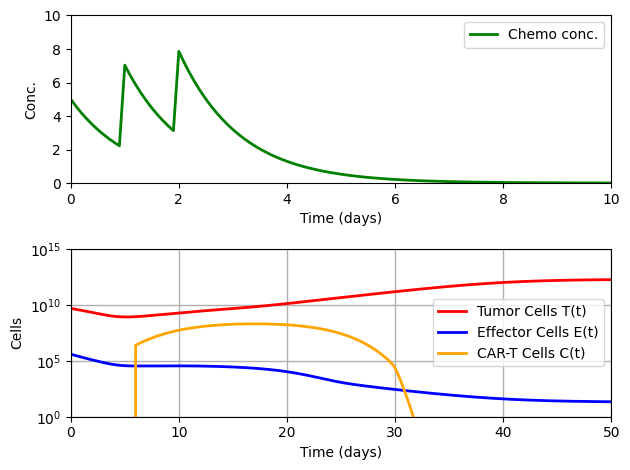

In [370]:
t, y = simulate(
    model,
    y0_pat_1,
    PARAMS_PAT_1,
    injection_times_M=injection_times_M_1,
    injection_time_C=injection_time_C_1,
    dosage_M=dosage_M_1,
    dosage_C=dosage_C_1,
    t_initial=0,
    t_final=50,
    time_step=0.1,
)

plot_graphs(t, y, xmax=50)

### Reproducing Figure 4

In [383]:
import itertools as it
import pandas as pd

In [256]:
# FIX THE NAMES OF THE OTHER THINGS

injection_times_C3, dosage_C3= [0, 1, 2], 5
injection_times_C5, dosage_C5= [0, 1, 2, 3, 4], 2.5
DL1 = 1e7
DL2 = 1e8
DL3 = 2.5e8
TB_12 = [1e9, 5e9, 1e10]    # patient 1/2 low, med, high
TB_34 = [1e8, 5e8, 9.8e8]    # patient 3/4 low, med, high

In [416]:
def find_max_rest_days(
    patient_idx: int,
    injection_times_CH: list[int],
    dosage_CH: float,
    DL: float,
    TB: float,
    success_thresh_tumor=1e2,
    plot=False,
    print_=False,
):
    params = {
        1: PARAMS_PAT_1,
        2: PARAMS_PAT_2,
        3: PARAMS_PAT_3,
        4: PARAMS_PAT_4,
    }[patient_idx]

    def success(rest_time: int) -> bool:
        t_vals, y_vals = simulate(
            model,
            [TB, 4e5, 0, 0],
            params,
            injection_times_M=injection_times_CH,   # oops bad naming, this is chemo
            dosage_M=dosage_CH,
            injection_time_C=injection_times_CH[-1] + rest_time,
            dosage_C=DL,
            t_initial=0,
            t_final=100,
            time_step=0.01
        )
        tumor_vals = y_vals[:, 0]

        if plot:
            plt.semilogy(t_vals, tumor_vals)
            plt.show()

        # could improve this heuristic
        min_tumor_val = min(tumor_vals)
        if print_:
            print(rest_time, min_tumor_val)

        return min_tumor_val < success_thresh_tumor

    rest_time = 2
    while rest_time < 50:
        if success(rest_time):
            rest_time += 1
        else:
            return rest_time - 1
        
    return "whoa"

In [418]:
def get_color(val: str):
    days = 1 if val == "x" else int(val)
    if days < 2:
        bg_color = "#cfa6a6"
    elif days == 2:
        bg_color = "#fabca6"
    elif 3 <= days < 5:
        bg_color = "#f9ffac"
    elif 5 <= days < 10:
        bg_color = "#b9fff4"
    elif 10 <= days < 15:
        bg_color = "#abc1ff"
    else:
        bg_color = "#a8a6d8"
    return f"background-color: {bg_color}; color: black; border: 1px gray"


# (1, 5), (3)
row_names = []
col_names = []
data = []

for row_idx, (pidx, TB_idx) in enumerate(it.product(range(1, 5), range(3))):
    row_names.append(f"P{pidx}: {['Low', 'Med', 'High'][TB_idx]} TB")
    data.append([])
    TB = (TB_12 if pidx <= 2 else TB_34)[TB_idx]
    for col_idx, (i, j) in enumerate(it.product(range(2), range(3))):  # (2), (3)
        if pidx - 1 == TB_idx == 0:
            col_names.append(f"C{[3, 5][i]}-DL{j+1}")
        print(row_names[row_idx], col_names[col_idx])
        injection_times_M, dosage_M, DL = (
            [injection_times_C3, injection_times_C5][i],
            [dosage_C3, dosage_C5][i],
            [DL1, DL2, DL3][j],
        )
        days = find_max_rest_days(pidx, injection_times_M, dosage_M, DL, TB)
        data[-1].append(f"{days}" if days >= 2 else "x")

df = pd.DataFrame(data, index=row_names, columns=col_names)
s = df.style.map(get_color)
s

P1: Low TB C3-DL1
P1: Low TB C3-DL2
P1: Low TB C3-DL3
P1: Low TB C5-DL1
P1: Low TB C5-DL2
P1: Low TB C5-DL3
P1: Med TB C3-DL1
P1: Med TB C3-DL2
P1: Med TB C3-DL3
P1: Med TB C5-DL1
P1: Med TB C5-DL2
P1: Med TB C5-DL3
P1: High TB C3-DL1
P1: High TB C3-DL2
P1: High TB C3-DL3
P1: High TB C5-DL1
P1: High TB C5-DL2
P1: High TB C5-DL3
P2: Low TB C3-DL1
P2: Low TB C3-DL2
P2: Low TB C3-DL3
P2: Low TB C5-DL1
P2: Low TB C5-DL2
P2: Low TB C5-DL3
P2: Med TB C3-DL1
P2: Med TB C3-DL2
P2: Med TB C3-DL3
P2: Med TB C5-DL1
P2: Med TB C5-DL2
P2: Med TB C5-DL3
P2: High TB C3-DL1
P2: High TB C3-DL2
P2: High TB C3-DL3
P2: High TB C5-DL1
P2: High TB C5-DL2
P2: High TB C5-DL3
P3: Low TB C3-DL1
Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
100.35310366919292 -0.002230353834681764 118634.99962617923 36293618.4605336 3.0018498462200195e-08
P3: Low TB C3-DL2
P3: Low TB C3-DL3
P3: Low TB C5-DL1
P3: Low TB C5-DL2
P3: Low TB C5-DL3
P3: Med TB C3-DL1

,C3-DL1,C3-DL2,C3-DL3,C5-DL1,C5-DL2,C5-DL3
P1: Low TB,7,8,9,7,9,9
P1: Med TB,x,2,2,x,2,3
P1: High TB,x,x,x,x,x,x
P2: Low TB,9,12,13,11,13,14
P2: Med TB,x,2,4,x,4,5
P2: High TB,x,x,x,x,x,x
P3: Low TB,5,5,6,4,5,5
P3: Med TB,2,3,3,2,2,3
P3: High TB,x,2,2,x,2,2
P4: Low TB,4,5,5,3,4,4
